In [1]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Alvos - Furto - Jan 2015 a Dez 2017.csv',
 'Alvos - Furto - Jan 2018 a Dez 2021.csv',
 'Alvos - Furto - Jan 2022 a Dez 2025.csv',
 'Alvos - Roubo - Jan 2015 a Dez 2025.csv',
 'clusters_municipios_perfil_temporal.csv',
 'Crimes Violentos - Jan 2012 a Dez 2021.csv',
 'Crimes Violentos - Jan 2022 a Dez 2025.csv',
 'Furto - Jan 2012 a Dez 2014.csv',
 'Furto - Jan 2015 a Dez 2017.csv',
 'Furto - Jan 2018 a Dez 2021.csv',
 'Furto - Jan 2022 a Dez 2025.csv',
 'Lesão Corporal - Jan 2012 a Dez 2018.csv',
 'Lesão Corporal - Jan 2019 a Dez 2025.csv',
 'Trablho_de_CD2 (1).ipynb',
 'Veiculos - Furto - Jan 2015 a Dez 2025.csv',
 'Veiculos - Roubo - Jan 2015 a Dez 2025.csv',
 'Vítimas de Homicidio Consumado - Jan 2012 a Dez 2025.csv']

In [2]:
mapa_colunas = {
    "número reds": "numero_reds",
    "qtde ocorrências": "quantidade_ocorrencias",
    "natureza principal completa": "natureza_principal_completa",
    "ano": "ano",

    "mês fato resumido": "mes_fato_resumido",
    "mês numérico fato": "mes",
    "data fato": "data_fato",
    "dia da semana fato": "dia_semana_fato",

    "horário fato": "horario_fato",
    "faixa 1 hora fato": "faixa_1h_fato",
    "faixa 6 horas fato": "faixa_6h_fato",

    "alvo": "alvo",
    "causa presumida": "causa_presumida",

    "desc longa meio utilizado": "descricao_longa_meio_utilizado",
    "descrição grupo local imediato": "descricao_grupo_local_imediato",
    "descrição local imediato": "descricao_local_imediato",

    "logradouro ocorrência - tipo": "tipo_logradouro_ocorrencia",
    "bairro - fato final": "bairro_fato",
    "bairro - fato final - municipio": "bairro_municipio",

    "municipio": "municipio",
    "município - código": "codigo_municipio",
    "uf - sigla": "uf",

    "risp": "risp",
    "rmbh": "rmbh",

    "descrição meio utilizado": "descricao_meio_utilizado",
    "qtde veículos": "quantidade_veiculos",
    "tipo veículo": "tipo_veiculo",
    "situação veículo": "situacao_veiculo",

    "qtd envolvidos": "quantidade_envolvidos",
    "descrição subclasse nat principal": "subclasse_natureza_principal",
    "tentado/consumado nat principal": "tentado_consumado",
    "natureza principal final": "natureza_principal_final",
    "natureza nomenclatura banco": "natureza_banco",

    "tipo_envolvimento_lesão_final": "tipo_envolvimento_lesao",
    "idade aparente": "idade_aparente",
    "sexo": "sexo",
    "cútis": "cutis",
    "escolaridade": "escolaridade",
    "relação vítima/autor": "relacao_vitima_autor",

    "tipo logradouro envolvido": "tipo_logradouro_envolvido",
    "bairro envolvido": "bairro_envolvido",
    "município envolvido": "municipio_envolvido",
    "uf envolvido - nome": "uf_envolvido"
}

colunas_remover = [
    "numero reds",
    "mes fato resumido",
    "mes numerico fato",
    "ano fato",
    "faixa_1h_fato",
    "faixa_6h_fato",
    "descricao grupo local imediato",
    "bairro_municipio",
    "municipio - codigo",
    "uf",
    "tipo_logradouro_envolvido",
    "bairro_envolvido",
    "municipio envolvido",
    "uf_envolvido"
]



In [3]:
import pandas as pd
import glob
import unicodedata

def padronizar_nome_coluna(col):
    col = col.strip().lower()
    col = unicodedata.normalize('NFKD', col)\
        .encode('ascii', 'ignore')\
        .decode('utf-8')
    col = col.replace('\ufeff', '')
    return col

caminho = "C:\\WINDOWS\\system32\\Untitled Folder/*.csv"
arquivos_csv = glob.glob(caminho)

datasets = []

for arquivo in arquivos_csv:
    try:
        df = pd.read_csv(arquivo, sep=';', encoding='utf-8')
    except:
        try:
            df = pd.read_csv(arquivo, sep=';', encoding='latin1')
        except:
            df = pd.read_csv(arquivo, sep=';', encoding='ISO-8859-1')

    # padroniza nomes
    df.columns = [padronizar_nome_coluna(c) for c in df.columns]

    # aplica mapa
    df.rename(columns=mapa_colunas, inplace=True)

    # remove colunas indesejadas
    df.drop(columns=colunas_remover, inplace=True, errors='ignore')

    datasets.append(df)


dataset_combinado = pd.concat(datasets, ignore_index=True)

print("Arquivos lidos com sucesso")
print(dataset_combinado.shape)
print(dataset_combinado.columns)


C:\Users\guilh\AppData\Local\Temp\ipykernel_27912\4226363182.py:23: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo, sep=';', encoding='latin1')
C:\Users\guilh\AppData\Local\Temp\ipykernel_27912\4226363182.py:23: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo, sep=';', encoding='latin1')


Arquivos lidos com sucesso
(9830630, 30)
Index(['qtde ocorrencias', 'natureza_principal_completa', 'data_fato',
       'dia_semana_fato', 'horario fato', 'alvo', 'causa_presumida',
       'descricao_longa_meio_utilizado', 'descricao local imediato',
       'logradouro ocorrencia - tipo', 'bairro_fato', 'municipio', 'risp',
       'rmbh',
       'municipio,madrugada,manha,noite,nao informado,tarde,cluster,dist_to_centroid',
       'descricao meio utilizado', 'qtde veiculos', 'tipo veiculo',
       'situacao veiculo', 'quantidade_envolvidos',
       'descricao subclasse nat principal', 'tentado_consumado',
       'natureza_principal_final', 'natureza_banco',
       'tipo_envolvimento_lesao_final', 'idade_aparente', 'sexo', 'cutis',
       'escolaridade', 'relacao vitima/autor'],
      dtype='object')


In [4]:
dataset_combinado.info()
dataset_combinado.describe()

dataset_combinado.isnull().sum() # quantidade de nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9830630 entries, 0 to 9830629
Data columns (total 30 columns):
 #   Column                                                                        Dtype  
---  ------                                                                        -----  
 0   qtde ocorrencias                                                              float64
 1   natureza_principal_completa                                                   object 
 2   data_fato                                                                     object 
 3   dia_semana_fato                                                               object 
 4   horario fato                                                                  object 
 5   alvo                                                                          object 
 6   causa_presumida                                                               object 
 7   descricao_longa_meio_utilizado                                 

qtde ocorrencias                                                                 461889
natureza_principal_completa                                                       46495
data_fato                                                                           861
dia_semana_fato                                                                     861
horario fato                                                                        861
alvo                                                                            5904460
causa_presumida                                                                   45108
descricao_longa_meio_utilizado                                                  5177448
descricao local imediato                                                         730625
logradouro ocorrencia - tipo                                                       2607
bairro_fato                                                                     1083372
municipio                       

In [6]:
threshold = 0.8  # remover colunas com mais de 80% de nulos
cols_to_drop = dataset_combinado.columns[
    dataset_combinado.isnull().mean() > threshold
]

dataset_combinado = dataset_combinado.drop(columns=cols_to_drop)

print(dataset_combinado.shape)
print(dataset_combinado.columns)

(9830630, 15)
Index(['qtde ocorrencias', 'natureza_principal_completa', 'data_fato',
       'dia_semana_fato', 'horario fato', 'alvo', 'causa_presumida',
       'descricao_longa_meio_utilizado', 'descricao local imediato',
       'logradouro ocorrencia - tipo', 'bairro_fato', 'municipio', 'risp',
       'rmbh', 'descricao meio utilizado'],
      dtype='object')


In [7]:
import pandas as pd
import numpy as np

#Limpeza básica
dataset_combinado['data_fato_limpa'] = (
    dataset_combinado['data_fato']
    .astype(str)
    .str.strip()
    .replace(['nan', 'NaN', 'None', 'NULL', 'null', '', '-', '--', '0000-00-00', '00/00/0000'], np.nan)
)

#Primeira tentativa: Formato ISO (AAAA-MM-DD)
dataset_combinado['data_fato_dt'] = pd.to_datetime(
    dataset_combinado['data_fato_limpa'],
    errors='coerce'
)

#Segunda tentativa: Apenas para quem deu erro (Formato DD/MM/AAAA)
mask_ainda_nulo = dataset_combinado['data_fato_dt'].isna() & dataset_combinado['data_fato_limpa'].notna()

dataset_combinado.loc[mask_ainda_nulo, 'data_fato_dt'] = pd.to_datetime(
    dataset_combinado.loc[mask_ainda_nulo, 'data_fato_limpa'],
    dayfirst=True,
    errors='coerce'
)

#Resultado final em String AAAA-MM-DD
dataset_combinado['data_fato_padronizada'] = dataset_combinado['data_fato_dt'].dt.strftime('%Y-%m-%d')

#Verificação
sucesso = dataset_combinado['data_fato_dt'].notna().sum()
falhas_restantes = dataset_combinado[dataset_combinado['data_fato_dt'].isna() & dataset_combinado['data_fato_limpa'].notna()].shape[0]

print(f"Sucesso total: {sucesso}")
print(f"Falhas reais (dados corrompidos): {falhas_restantes}")

#Remove as colunas auxiliares e a bruta
colunas_para_remover = ['data_fato', 'data_fato_limpa', 'data_fato_padronizada']
dataset_combinado.drop(columns=colunas_para_remover, inplace=True)

#Renomeia a coluna convertida para o nome original (opcional, mas recomendado)
dataset_combinado.rename(columns={'data_fato_dt': 'data_fato'}, inplace=True)

#Verifica o resultado final
print(dataset_combinado.info())
print(dataset_combinado.head())
print(dataset_combinado.shape)
print(dataset_combinado.columns)

Sucesso total: 9829769
Falhas reais (dados corrompidos): 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9830630 entries, 0 to 9830629
Data columns (total 15 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   qtde ocorrencias                float64       
 1   natureza_principal_completa     object        
 2   dia_semana_fato                 object        
 3   horario fato                    object        
 4   alvo                            object        
 5   causa_presumida                 object        
 6   descricao_longa_meio_utilizado  object        
 7   descricao local imediato        object        
 8   logradouro ocorrencia - tipo    object        
 9   bairro_fato                     object        
 10  municipio                       object        
 11  risp                            object        
 12  rmbh                            object        
 13  descricao meio utilizado        object     

In [8]:
import pandas as pd
import numpy as np

# 1. Converter a string de horário para o tipo Timedelta ou extrair apenas a hora
# Usamos expand=True para pegar apenas a primeira parte antes dos ':'
horas = pd.to_numeric(
    dataset_combinado['horario fato'].astype(str).str.split(':').str[0],
    errors='coerce'
)

# 2. Definir as faixas usando pd.cut (muito mais rápido que .apply)
# Definimos os limites: 0, 6, 12, 18 e 24
bins = [0, 6, 12, 18, 24]
labels = ['Madrugada', 'Manhã', 'Tarde', 'Noite']

# O parâmetro 'right=False' garante que 06:00 seja Manhã e não Madrugada (limite esquerdo incluso)
dataset_combinado['faixa_horaria'] = pd.cut(
    horas,
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# 3. Tratamento de exceção: Se houver horários como "24:00:00" ou erros
dataset_combinado['faixa_horaria'] = dataset_combinado['faixa_horaria'].astype(str).replace('nan', 'Não Informado')

# Se quiser substituir a coluna original:
# dataset_combined['horario fato'] = dataset_combined['faixa_horaria']

#Verifica o resultado final
print(dataset_combinado.info())
print(dataset_combinado.head())
print(dataset_combinado.shape)
print(dataset_combinado.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9830630 entries, 0 to 9830629
Data columns (total 16 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   qtde ocorrencias                float64       
 1   natureza_principal_completa     object        
 2   dia_semana_fato                 object        
 3   horario fato                    object        
 4   alvo                            object        
 5   causa_presumida                 object        
 6   descricao_longa_meio_utilizado  object        
 7   descricao local imediato        object        
 8   logradouro ocorrencia - tipo    object        
 9   bairro_fato                     object        
 10  municipio                       object        
 11  risp                            object        
 12  rmbh                            object        
 13  descricao meio utilizado        object        
 14  data_fato                       datetime64[ns]
 15

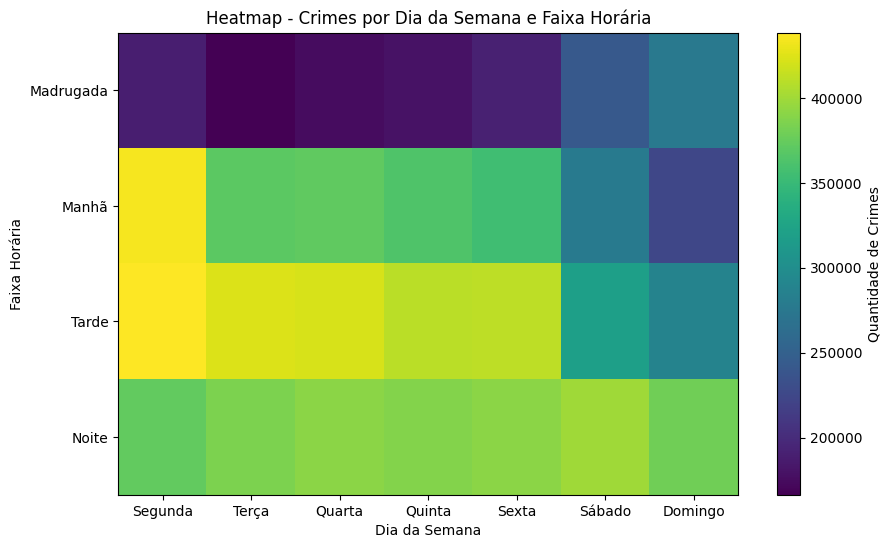


Total de crimes por dia da semana:
dia_semana_fato
Segunda    1434806.0
Quarta     1360833.0
Sexta      1348459.0
Terça      1345673.0
Quinta     1340764.0
Sábado     1241169.0
Domingo    1168537.0
dtype: float64

Dias que tiveram crimes:
dia_semana_fato
Segunda    1434806.0
Terça      1345673.0
Quarta     1360833.0
Quinta     1340764.0
Sexta      1348459.0
Sábado     1241169.0
Domingo    1168537.0
dtype: float64

Dia com mais crimes: Segunda (1434806.0)


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# CONFIGURAÇÕES DE ORDEM
# =========================
ordem_faixa = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
ordem_dia = [1, 2, 3, 4, 5, 6, 7]

mapa_dias = {
    1: 'Segunda',
    2: 'Terça',
    3: 'Quarta',
    4: 'Quinta',
    5: 'Sexta',
    6: 'Sábado',
    7: 'Domingo'
}

# =========================
# CRIAÇÃO DA MATRIZ
# =========================
tabela = (
    dataset_combinado
    .groupby(['dia_semana_fato', 'faixa_horaria'])['qtde ocorrencias']
    .sum()
    .unstack(fill_value=0)
)

# Reordenar
tabela = tabela.reindex(index=ordem_dia, columns=ordem_faixa)

# Trocar número do dia por nome
tabela.index = tabela.index.map(mapa_dias)

# Transpor (turnos no eixo Y)
tabela = tabela.T

# =========================
# HEATMAP
# =========================
plt.figure(figsize=(10,6))
plt.imshow(tabela, aspect='auto')

plt.xticks(np.arange(len(tabela.columns)), tabela.columns)
plt.yticks(np.arange(len(tabela.index)), tabela.index)

plt.colorbar(label='Quantidade de Crimes')
plt.title('Heatmap - Crimes por Dia da Semana e Faixa Horária')
plt.xlabel('Dia da Semana')
plt.ylabel('Faixa Horária')

plt.show()

# =========================
# ANÁLISE DOS DIAS
# =========================

total_por_dia = tabela.sum(axis=0)

print('\nTotal de crimes por dia da semana:')
print(total_por_dia.sort_values(ascending=False))

print('\nDias que tiveram crimes:')
print(total_por_dia[total_por_dia > 0])

dia_mais_crime = total_por_dia.idxmax()
valor_maximo = total_por_dia.max()

print(f'\nDia com mais crimes: {dia_mais_crime} ({valor_maximo})')


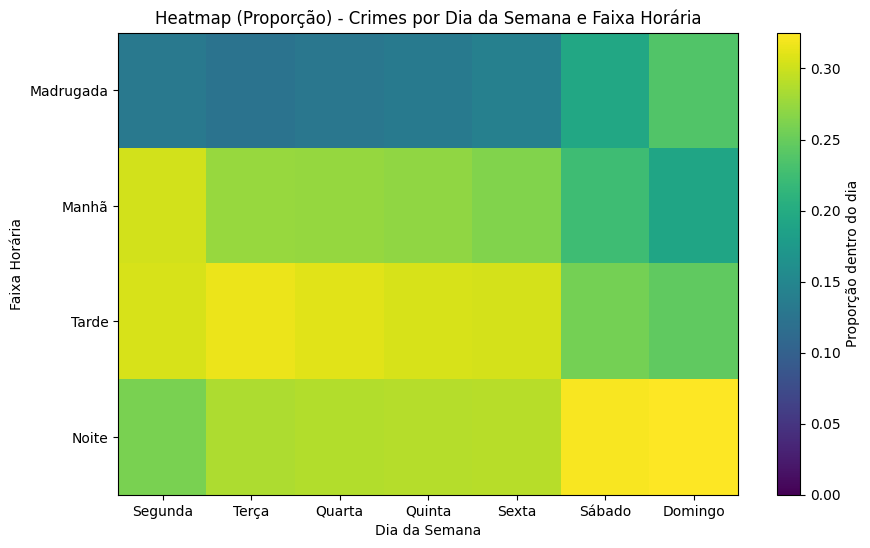

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ordem_faixa = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
ordem_dia = [1, 2, 3, 4, 5, 6, 7]

mapa_dias = {1:'Segunda',2:'Terça',3:'Quarta',4:'Quinta',5:'Sexta',6:'Sábado',7:'Domingo'}

tabela = (
    dataset_combinado
    .groupby(['dia_semana_fato','faixa_horaria'])['qtde ocorrencias']
    .sum()
    .unstack(fill_value=0)
).reindex(index=ordem_dia, columns=ordem_faixa)

# Normalização por dia (cada coluna soma 1 depois da transposição)
tabela.index = tabela.index.map(mapa_dias)
tabela = tabela.T

tabela_prop = tabela.div(tabela.sum(axis=0), axis=1)  # divide cada coluna pelo total do dia

plt.figure(figsize=(10,6))
plt.imshow(tabela_prop, aspect='auto', vmin=0, vmax=tabela_prop.to_numpy().max())

plt.xticks(np.arange(len(tabela_prop.columns)), tabela_prop.columns)
plt.yticks(np.arange(len(tabela_prop.index)), tabela_prop.index)

plt.colorbar(label='Proporção dentro do dia')
plt.title('Heatmap (Proporção) - Crimes por Dia da Semana e Faixa Horária')
plt.xlabel('Dia da Semana')
plt.ylabel('Faixa Horária')
plt.show()

In [ ]:
import re

padrao_violento = re.compile(
    r"HOMIC|ROUBO|LATROCIN|ESTUPRO|LES[AÃ]O|SEQUESTRO|EXTORS",
    re.IGNORECASE
)

dataset_combinado["crime_violento"] = (
    dataset_combinado["natureza_principal_completa"]
    .fillna("")
    .apply(lambda x: 1 if padrao_violento.search(x) else 0)
)
p_violento = (
    (dataset_combinado["crime_violento"] *
     dataset_combinado["qtde ocorrencias"]).sum()
    / dataset_combinado["qtde ocorrencias"].sum()
)

print("Proporção geral ponderada:", p_violento)

In [ ]:
dataset_combinado["usa_arma_fogo"] = (
    dataset_combinado["descricao_longa_meio_utilizado"]
    .fillna("")
    .str.upper()
    .str.contains("ARMA DE FOGO", na=False)
    .astype(int)
)

p_arma_fogo = (
    (dataset_combinado["usa_arma_fogo"] * dataset_combinado["qtde ocorrencias"]).sum()
    / dataset_combinado["qtde ocorrencias"].sum()
)

print("Proporção geral (ponderada) de ocorrências com arma de fogo:", p_arma_fogo)

arma_por_faixa = (
    dataset_combinado
    .groupby("faixa_horaria")
    .apply(lambda x:
        (x["usa_arma_fogo"] * x["qtde ocorrencias"]).sum()
        / x["qtde ocorrencias"].sum()
    )
    .sort_values(ascending=False)
)

print(arma_por_faixa)

arma_por_risp = (
    dataset_combinado
    .groupby("risp")
    .apply(lambda x:
        (x["usa_arma_fogo"] * x["qtde ocorrencias"]).sum()
        / x["qtde ocorrencias"].sum()
    )
    .sort_values(ascending=False)
)

print(arma_por_risp)

arma_risp_faixa = dataset_combinado.groupby(
    ["risp", "faixa_horaria"]
).apply(lambda x:
    (x["usa_arma_fogo"] * x["qtde ocorrencias"]).sum()
    / x["qtde ocorrencias"].sum()
).unstack()

print(arma_risp_faixa)

tabela_arma = dataset_combinado.groupby(
    ["faixa_horaria"]
).apply(lambda x:
    pd.Series({
        "arma": (x["usa_arma_fogo"] * x["qtde ocorrencias"]).sum(),
        "sem_arma": ((1 - x["usa_arma_fogo"]) * x["qtde ocorrencias"]).sum()
    })
)

from scipy.stats import chi2_contingency

chi2, p, _, _ = chi2_contingency(tabela_arma)
print("p-valor ponderado:", p)

C:\Users\guilh\AppData\Local\Temp\ipykernel_27912\2282399382.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["crime_violento"] * x["qtde ocorrencias"]).sum())


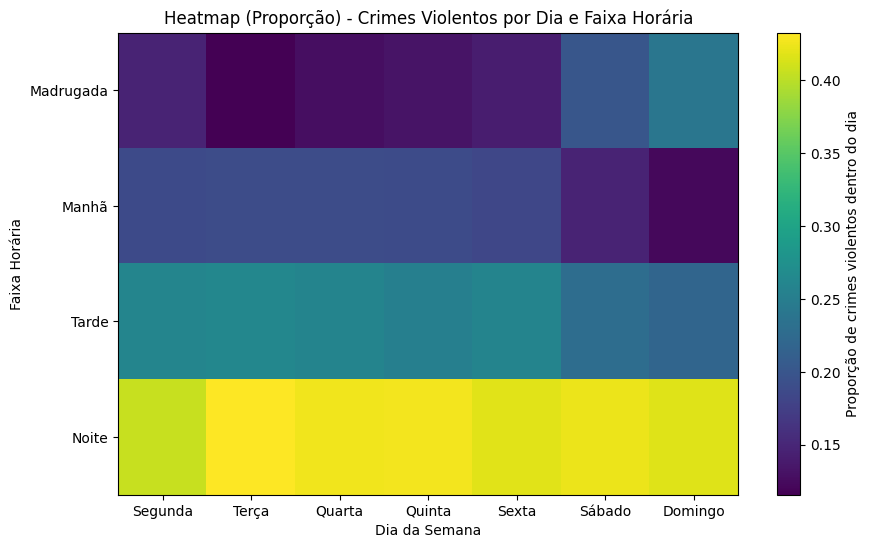

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Matriz de crimes violentos (ponderado)
tabela_viol = (
    dataset_combinado
    .groupby(["dia_semana_fato", "faixa_horaria"])["qtde ocorrencias"]
    .apply(lambda s: 0)  # placeholder só pra manter estrutura (não use)
)

tabela_viol = (
    dataset_combinado
    .groupby(["dia_semana_fato", "faixa_horaria"])
    .apply(lambda x: (x["crime_violento"] * x["qtde ocorrencias"]).sum())
    .unstack(fill_value=0)
    .reindex(index=ordem_dia, columns=ordem_faixa)
)

# 2) Ajustar nomes e orientar (faixas no eixo Y)
tabela_viol.index = tabela_viol.index.map(mapa_dias)
tabela_viol = tabela_viol.T

# 3) Proporção dentro de cada dia (normalização por coluna)
tabela_viol_prop = tabela_viol.div(tabela_viol.sum(axis=0), axis=1)

# 4) Plot do heatmap
plt.figure(figsize=(10, 6))
plt.imshow(tabela_viol_prop, aspect="auto")

plt.xticks(np.arange(len(tabela_viol_prop.columns)), tabela_viol_prop.columns)
plt.yticks(np.arange(len(tabela_viol_prop.index)), tabela_viol_prop.index)

plt.colorbar(label="Proporção de crimes violentos dentro do dia")
plt.title("Heatmap (Proporção) - Crimes Violentos por Dia e Faixa Horária")
plt.xlabel("Dia da Semana")
plt.ylabel("Faixa Horária")
plt.show()

C:\Users\guilh\AppData\Local\Temp\ipykernel_27912\1658745965.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['usa_arma_fogo'] * x['qtde ocorrencias']).sum())


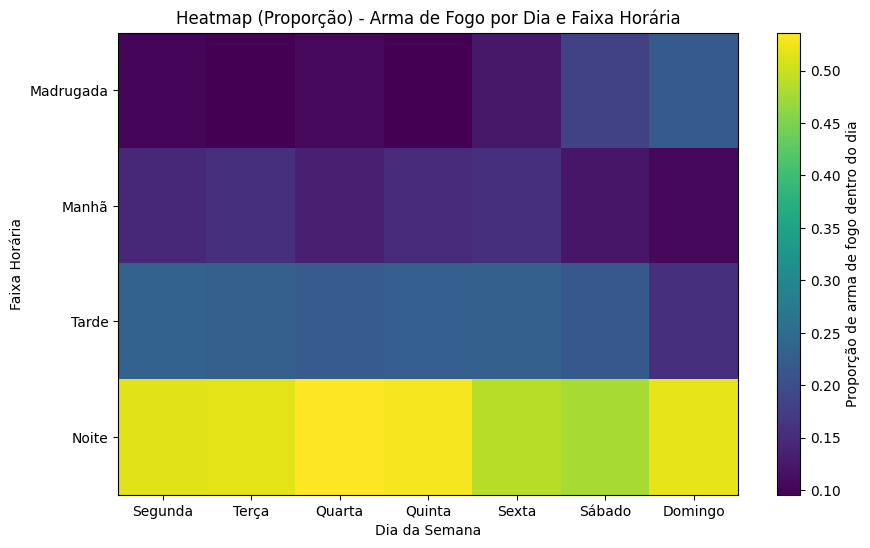

In [18]:
tabela_arma = (
    dataset_combinado
    .groupby(['dia_semana_fato','faixa_horaria'])
    .apply(lambda x: (x['usa_arma_fogo'] * x['qtde ocorrencias']).sum())
    .unstack(fill_value=0)
).reindex(index=ordem_dia, columns=ordem_faixa)

tabela_arma.index = tabela_arma.index.map(mapa_dias)
tabela_arma = tabela_arma.T

tabela_arma_prop = tabela_arma.div(tabela_arma.sum(axis=0), axis=1)

plt.figure(figsize=(10,6))
plt.imshow(tabela_arma_prop, aspect='auto')

plt.xticks(np.arange(len(tabela_arma_prop.columns)), tabela_arma_prop.columns)
plt.yticks(np.arange(len(tabela_arma_prop.index)), tabela_arma_prop.index)

plt.colorbar(label='Proporção de arma de fogo dentro do dia')
plt.title('Heatmap (Proporção) - Arma de Fogo por Dia e Faixa Horária')
plt.xlabel('Dia da Semana')
plt.ylabel('Faixa Horária')
plt.show()

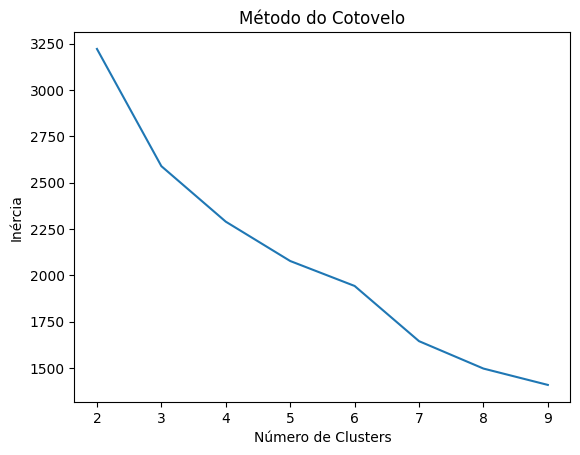

In [19]:
df_cluster = (
    dataset_combinado
    .groupby(['municipio', 'faixa_horaria'])['qtde ocorrencias']
    .sum()
    .unstack(fill_value=0)
)

# transformar em proporção (perfil)
df_cluster = df_cluster.div(df_cluster.sum(axis=1), axis=0)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# padronização
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster)

# modelo
kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X)

inercia = []

for k in range(2, 10):
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(X)
    inercia.append(modelo.inertia_)

plt.plot(range(2,10), inercia)
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.show()

In [20]:
from sklearn.metrics import silhouette_score

for k in range(2,8):
    modelo = KMeans(n_clusters=k, random_state=42)
    labels = modelo.fit_predict(X)
    print(k, silhouette_score(X, labels))

2 0.31519168750570054
3 0.3317575042749589
4 0.2223785249884104
5 0.23539369178053118
6 0.20599386754963056
7 0.21480418422030503


Silhouette final (K=3): 0.3220

Perfil temporal médio por cluster (proporções):
faixa_horaria  Madrugada     Manhã     Noite  Não Informado     Tarde
cluster                                                              
0               0.229591  0.195952  0.322136       0.000044  0.252277
1               0.218132  0.252641  0.267753       0.000036  0.261438
2               0.158837  0.268748  0.272369       0.000014  0.300033


<Figure size 1000x500 with 0 Axes>

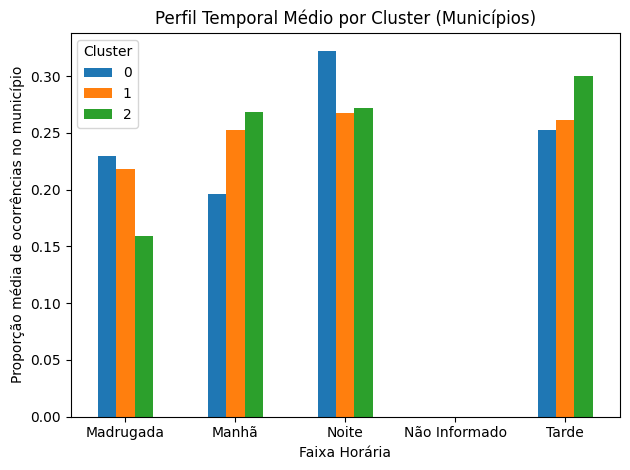


Quantidade de municípios por cluster:
cluster
0    241
1    274
2    346
Name: count, dtype: int64

Exemplo de municípios (20 primeiros) por cluster:
cluster
0    [AGUA BOA, AGUA COMPRIDA, AGUANIL, AGUAS VERME...
1    [ABRE-CAMPO, ACAIACA, AGUAS FORMOSAS, AIURUOCA...
2    [ABADIA DOS DOURADOS, ABAETE, ACUCENA, AIMORES...
Name: municipio, dtype: object

Top 10 municípios mais representativos (por cluster):
faixa_horaria  cluster               municipio  dist_to_centroid
475                  0          MATIAS CARDOSO          0.397848
856                  0            VIRGINOPOLIS          0.438731
187                  0              COMERCINHO          0.522811
139                  0         CAPITAO ANDRADE          0.540349
453                  0             MALACACHETA          0.542084
616                  0                    POTE          0.547111
703                  0  SANTO ANTONIO DO GRAMA          0.549421
424                  0               JUVENILIA          0.562295
182  

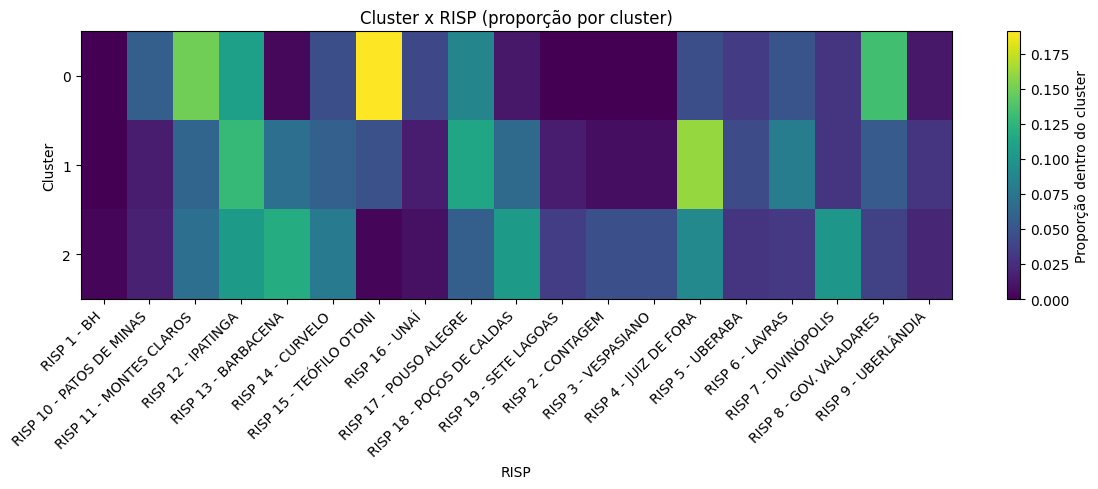


Arquivo gerado: clusters_municipios_perfil_temporal.csv


In [21]:
# =========================
# PRÓXIMOS PASSOS (OBJETIVO 1: padrões espaço-temporais)
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---------------------------------------------------------
# 0) Escolha de K (com base no seu silhouette)
#    Melhor foi K=3 (0.3317...), então vamos fixar K=3.
# ---------------------------------------------------------
K_FINAL = 3
SEED = 42

# ---------------------------------------------------------
# 1) Garantir que df_cluster está como você montou:
#    index = municipio
#    colunas = ['Madrugada','Manhã','Tarde','Noite'] (proporções)
# ---------------------------------------------------------
# df_cluster = (
#     dataset_combinado.groupby(['municipio', 'faixa_horaria'])['quantidade_ocorrencias']
#     .sum().unstack(fill_value=0)
# )
# df_cluster = df_cluster.div(df_cluster.sum(axis=1), axis=0)

# Se por acaso ainda existir linha com soma=0 (para evitar NaN):
df_cluster = df_cluster.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

# ---------------------------------------------------------
# 2) Padronizar e treinar o KMeans final
# ---------------------------------------------------------
scaler = StandardScaler()
X = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init="auto")
labels = kmeans.fit_predict(X)

# anexar cluster ao df_cluster
df_cluster_final = df_cluster.copy()
df_cluster_final["cluster"] = labels

# checar silhouette do modelo final
sil = silhouette_score(X, labels)
print(f"Silhouette final (K={K_FINAL}): {sil:.4f}")

# ---------------------------------------------------------
# 3) PERFIL TEMPORAL por cluster (médias das proporções)
#    -> isso é o "padrão temporal" que você vai descrever no relatório
# ---------------------------------------------------------
perfil_cluster = df_cluster_final.groupby("cluster").mean(numeric_only=True)
print("\nPerfil temporal médio por cluster (proporções):")
print(perfil_cluster)

# ---------------------------------------------------------
# 4) Visualização: barras do perfil temporal por cluster
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
perfil_cluster.T.plot(kind="bar")
plt.title("Perfil Temporal Médio por Cluster (Municípios)")
plt.xlabel("Faixa Horária")
plt.ylabel("Proporção média de ocorrências no município")
plt.xticks(rotation=0)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5) INSPEÇÃO ESPACIAL: quais municípios caíram em cada cluster
#    -> isso é o "padrão espacial" (agrupamento de municípios por perfil temporal)
# ---------------------------------------------------------
print("\nQuantidade de municípios por cluster:")
print(df_cluster_final["cluster"].value_counts().sort_index())

# lista curta de municípios por cluster (para inspeção manual)
municipios_por_cluster = (
    df_cluster_final.reset_index()
    .groupby("cluster")["municipio"]
    .apply(lambda s: list(s)[:20])  # mostra só os 20 primeiros
)
print("\nExemplo de municípios (20 primeiros) por cluster:")
print(municipios_por_cluster)

# ---------------------------------------------------------
# 6) MUNICÍPIOS "mais representativos" de cada cluster:
#    (menor distância ao centróide = mais típico)
# ---------------------------------------------------------
from numpy.linalg import norm

centroids = kmeans.cluster_centers_
dist = np.vstack([norm(X - centroids[c], axis=1) for c in range(K_FINAL)]).T
df_cluster_final["dist_to_centroid"] = dist[np.arange(len(labels)), labels]

top_representativos = (
    df_cluster_final.reset_index()
    .sort_values(["cluster", "dist_to_centroid"])
    .groupby("cluster")
    .head(10)[["cluster", "municipio", "dist_to_centroid"]]
)

print("\nTop 10 municípios mais representativos (por cluster):")
print(top_representativos)

# ---------------------------------------------------------
# 7) (OPCIONAL, mas MUITO bom pro objetivo espacial)
#    Relacionar clusters com RISP (ou outra regional) se existir no dataset_combinado.
#    Isso evidencia se certos perfis temporais se concentram em certas regiões.
# ---------------------------------------------------------
if "risp" in dataset_combinado.columns:
    # pegar a RISP mais frequente por município (mode)
    municipio_risp = (
        dataset_combinado.dropna(subset=["municipio", "risp"])
        .groupby("municipio")["risp"]
        .agg(lambda x: x.mode().iat[0] if len(x.mode()) > 0 else x.iloc[0])
    )

    df_cluster_geo = df_cluster_final.join(municipio_risp, how="left")

    tabela_cluster_risp = pd.crosstab(
        df_cluster_geo["cluster"],
        df_cluster_geo["risp"],
        normalize="index"
    )

    print("\nDistribuição de RISP dentro de cada cluster (proporção por cluster):")
    print(tabela_cluster_risp)

    plt.figure(figsize=(12, 5))
    plt.imshow(tabela_cluster_risp.values, aspect="auto")
    plt.xticks(range(len(tabela_cluster_risp.columns)), tabela_cluster_risp.columns, rotation=45, ha="right")
    plt.yticks(range(len(tabela_cluster_risp.index)), tabela_cluster_risp.index)
    plt.colorbar(label="Proporção dentro do cluster")
    plt.title("Cluster x RISP (proporção por cluster)")
    plt.xlabel("RISP")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 8) Salvar resultados para usar no relatório e gráficos
# ---------------------------------------------------------
df_cluster_final.reset_index().to_csv("clusters_municipios_perfil_temporal.csv", index=False)
print("\nArquivo gerado: clusters_municipios_perfil_temporal.csv")

In [23]:
pd.crosstab(
    df_cluster_geo["cluster"],
    df_cluster_geo["risp"],
    normalize="columns"
)

risp,RISP 1 - BH,RISP 10 - PATOS DE MINAS,RISP 11 - MONTES CLAROS,RISP 12 - IPATINGA,RISP 13 - BARBACENA,RISP 14 - CURVELO,RISP 15 - TEÓFILO OTONI,RISP 16 - UNAÍ,RISP 17 - POUSO ALEGRE,RISP 18 - POÇOS DE CALDAS,RISP 19 - SETE LAGOAS,RISP 2 - CONTAGEM,RISP 3 - VESPASIANO,RISP 4 - JUIZ DE FORA,RISP 5 - UBERABA,RISP 6 - LAVRAS,RISP 7 - DIVINÓPOLIS,RISP 8 - GOV. VALADARES,RISP 9 - UBERLÂNDIA
cluster,,,,,,,,,,,,,,,,,,,
0,0.0,0.583333,0.467532,0.268041,0.016393,0.203704,0.766667,0.588235,0.291667,0.052632,0.00,0.000000,0.000000,0.127907,0.266667,0.266667,0.14,0.533333,0.166667
1,0.0,0.166667,0.220779,0.360825,0.311475,0.296296,0.216667,0.235294,0.430556,0.315789,0.25,0.111111,0.111111,0.511628,0.400000,0.488889,0.16,0.250000,0.444444
2,1.0,0.250000,0.311688,0.371134,0.672131,0.500000,0.016667,0.176471,0.277778,0.631579,0.75,0.888889,0.888889,0.360465,0.333333,0.244444,0.70,0.216667,0.388889


In [24]:
tabela = pd.crosstab(
    df_cluster_geo["cluster"],
    df_cluster_geo["risp"],
    normalize="columns"
)

indice_concentracao = tabela.max()
print(indice_concentracao.sort_values(ascending=False))

risp
RISP 1 - BH                  1.000000
RISP 2 - CONTAGEM            0.888889
RISP 3 - VESPASIANO          0.888889
RISP 15 - TEÓFILO OTONI      0.766667
RISP 19 - SETE LAGOAS        0.750000
RISP 7 - DIVINÓPOLIS         0.700000
RISP 13 - BARBACENA          0.672131
RISP 18 - POÇOS DE CALDAS    0.631579
RISP 16 - UNAÍ               0.588235
RISP 10 - PATOS DE MINAS     0.583333
RISP 8 - GOV. VALADARES      0.533333
RISP 4 - JUIZ DE FORA        0.511628
RISP 14 - CURVELO            0.500000
RISP 6 - LAVRAS              0.488889
RISP 11 - MONTES CLAROS      0.467532
RISP 9 - UBERLÂNDIA          0.444444
RISP 17 - POUSO ALEGRE       0.430556
RISP 5 - UBERABA             0.400000
RISP 12 - IPATINGA           0.371134
dtype: float64


In [25]:
from scipy.stats import entropy

diversidade = tabela.apply(lambda col: entropy(col), axis=0)
print(diversidade.sort_values())

risp
RISP 1 - BH                  0.000000
RISP 2 - CONTAGEM            0.348832
RISP 3 - VESPASIANO          0.348832
RISP 19 - SETE LAGOAS        0.562335
RISP 15 - TEÓFILO OTONI      0.603314
RISP 13 - BARBACENA          0.697746
RISP 18 - POÇOS DE CALDAS    0.809205
RISP 7 - DIVINÓPOLIS         0.818141
RISP 16 - UNAÍ               0.958692
RISP 10 - PATOS DE MINAS     0.959615
RISP 4 - JUIZ DE FORA        0.973710
RISP 8 - GOV. VALADARES      1.013201
RISP 9 - UBERLÂNDIA          1.026331
RISP 14 - CURVELO            1.031098
RISP 6 - LAVRAS              1.046692
RISP 11 - MONTES CLAROS      1.052317
RISP 17 - POUSO ALEGRE       1.078010
RISP 5 - UBERABA             1.085189
RISP 12 - IPATINGA           1.088583
dtype: float64


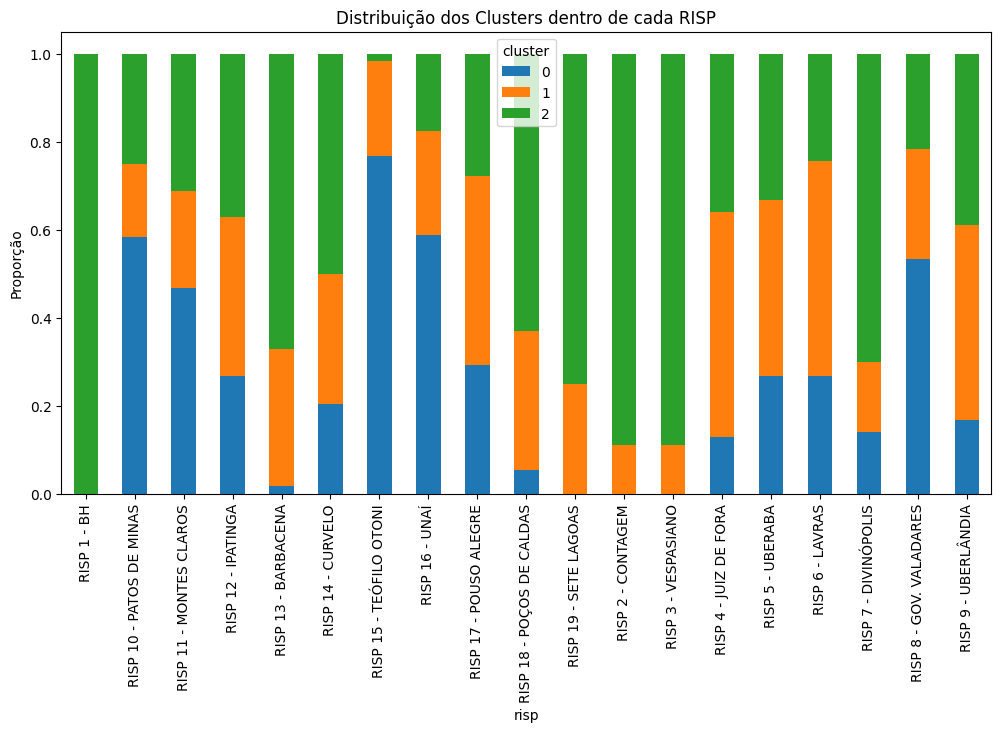

In [26]:
tabela.T.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Distribuição dos Clusters dentro de cada RISP")
plt.ylabel("Proporção")
plt.show()

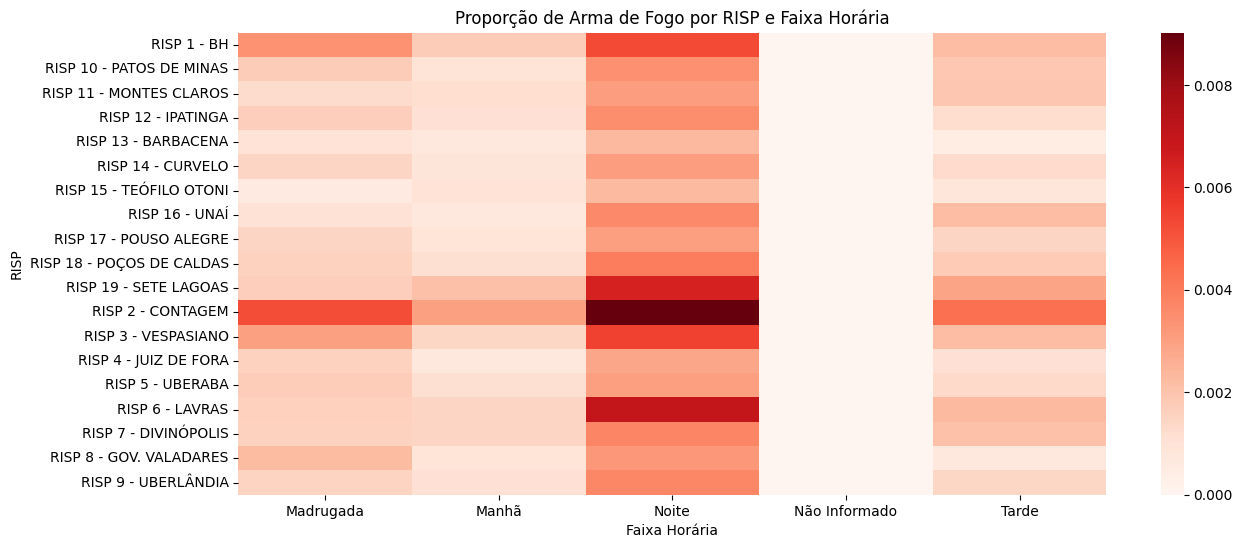

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.heatmap(arma_risp_faixa, cmap="Reds", annot=False)
plt.title("Proporção de Arma de Fogo por RISP e Faixa Horária")
plt.ylabel("RISP")
plt.xlabel("Faixa Horária")
plt.show()

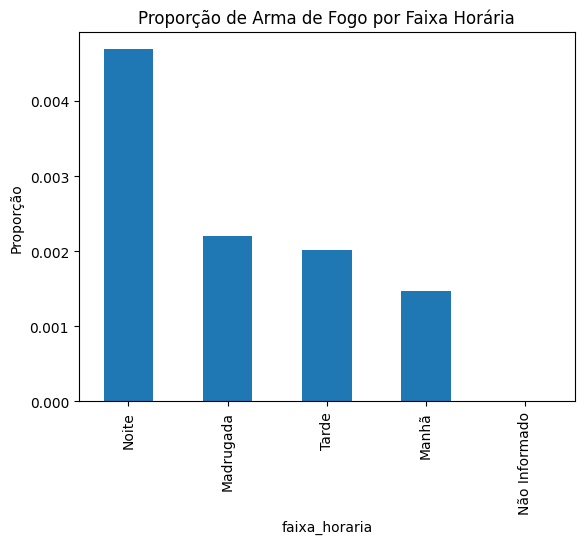

In [29]:
arma_por_faixa.plot(kind="bar")
plt.title("Proporção de Arma de Fogo por Faixa Horária")
plt.ylabel("Proporção")
plt.show()

In [30]:
from scipy.stats import chi2_contingency

tabela_horario = pd.crosstab(
    dataset_combinado["faixa_horaria"],
    dataset_combinado["usa_arma_fogo"]
)

chi2, p, _, _ = chi2_contingency(tabela_horario)

print("p-valor:", p)

tabela_risp = pd.crosstab(
    dataset_combinado["risp"],
    dataset_combinado["usa_arma_fogo"]
)

chi2, p, _, _ = chi2_contingency(tabela_risp)

print("p-valor:", p)

p-valor: 0.0
p-valor: 0.0


In [31]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

print("Cramer's V ponderado:", cramers_v(tabela_arma))

Cramer's V ponderado: 0.025348045850772903


In [33]:
dataset_combinado["tipo_local"] = (
    dataset_combinado["logradouro ocorrencia - tipo"]
    .fillna("")
    .str.upper()
)

violencia_por_local = (
    dataset_combinado
    .groupby("tipo_local")
    .apply(lambda x:
        (x["crime_violento"] * x["qtde ocorrencias"]).sum()
        / x["qtde ocorrencias"].sum()
    )
    .sort_values(ascending=False)
)

print(violencia_por_local.head(15))

tipo_local
CIRCULAR         1.000000
ELEVADOR         1.000000
BAIXO            1.000000
FOLHA            1.000000
NAO INFORMADO    1.000000
PENITENCIARIA    0.826715
TRINCHEIRA       0.769231
CONVENTO         0.666667
BAIXA            0.600000
ELEVADO          0.600000
ALDEIA           0.599490
TUNEL            0.581395
ADRO             0.555556
PASSARELA        0.531915
CRUZAMENTO       0.510222
dtype: float64


C:\Users\guilh\AppData\Local\Temp\ipykernel_27912\214875489.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:


In [34]:
min_ocorrencias = 1000  # pode ajustar

tabela_local = dataset_combinado.groupby("tipo_local").apply(
    lambda x: pd.Series({
        "violentos": (x["crime_violento"] * x["qtde ocorrencias"]).sum(),
        "total": x["qtde ocorrencias"].sum()
    })
)

# Filtrar categorias com volume suficiente
tabela_local = tabela_local[tabela_local["total"] >= min_ocorrencias]

tabela_local["proporcao"] = (
    tabela_local["violentos"] / tabela_local["total"]
)

tabela_local = tabela_local.sort_values("proporcao", ascending=False)

tabela_local.head(10)

C:\Users\guilh\AppData\Local\Temp\ipykernel_27912\921677650.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabela_local = dataset_combinado.groupby("tipo_local").apply(


,violentos,total,proporcao
tipo_local,,,
CRUZAMENTO,2346.0,4598.0,0.510222
,800.0,1680.0,0.476190
VIA,5496.0,12359.0,0.444696
BECO,6089.0,14155.0,0.430166
COLONIZACAO,662.0,1584.0,0.417929
MARGINAL,508.0,1405.0,0.361566
RODOVIA,115246.0,324266.0,0.355406
OUTRO,1543.0,4460.0,0.345964
VILA,2935.0,8674.0,0.338368


In [35]:
import pandas as pd

tabela = dataset_combinado.groupby("tipo_local").apply(
    lambda x: pd.Series({
        "violento": (x["crime_violento"] * x["qtde ocorrencias"]).sum(),
        "nao_violento": ((1 - x["crime_violento"]) * x["qtde ocorrencias"]).sum()
    })
)

from scipy.stats import chi2_contingency

chi2, p, _, _ = chi2_contingency(tabela)

print("p-valor ponderado:", p)

p-valor ponderado: 0.0


C:\Users\guilh\AppData\Local\Temp\ipykernel_27912\4104516153.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabela = dataset_combinado.groupby("tipo_local").apply(


In [36]:
import numpy as np

def cramers_v_matrix(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

print("Cramer's V ponderado:", cramers_v_matrix(tabela))

Cramer's V ponderado: 0.08079875451497655


In [44]:
tabela_local = dataset_combinado.groupby("tipo_local").apply(
    lambda x: pd.Series({
        "violentos": (x["crime_violento"] * x["qtde ocorrencias"]).sum(),
        "total": x["qtde ocorrencias"].sum()
    })
)

# Definir mínimo aceitável
min_total = 500  # você pode testar 1000 também

tabela_local = tabela_local[tabela_local["total"] >= min_total]

tabela_local["proporcao"] = (
    tabela_local["violentos"] / tabela_local["total"]
)

tabela_local = tabela_local.sort_values("proporcao", ascending=False)

tabela_local["proporcao"].head(10)

C:\Users\guilh\AppData\Local\Temp\ipykernel_27912\3351394298.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabela_local = dataset_combinado.groupby("tipo_local").apply(


tipo_local
PREENCHIMENTO OPCIONAL                               1.000000
UNIDADE PRISIONAL (CERESP/PRESIDIO/PENITENCIARIA)    0.944471
CENTRO DE INTERNACAO DE ADOLESCENTES                 0.882753
CADEIA PUBLICA                                       0.848659
AGENCIA DE CORREIO                                   0.569193
CONFEITARIA / PADARIA / PANIFICADORA                 0.542585
POSTO DE COMBUSTIVEL                                 0.491548
JOALHERIA                                            0.435061
MOTEL / DRIVE-IN                                     0.423443
CASA LOTERICA                                        0.381887
Name: proporcao, dtype: float64

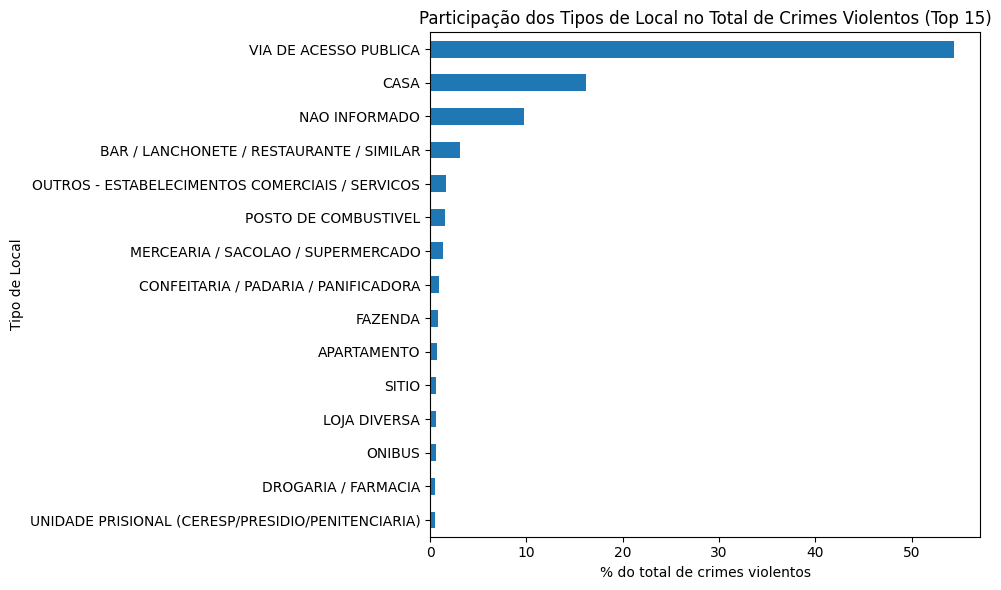

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Garanta que tipo_local existe (ajuste o nome se necessário)
dataset_combinado["tipo_local"] = (
    dataset_combinado["descricao local imediato"]
    .fillna("")
    .str.strip()
    .replace("", "NAO INFORMADO")
    .str.upper()
)

# Peso de violentos (ponderado por qtde ocorrencias)
violentos_por_tipo = (
    dataset_combinado
    .assign(viol_peso=lambda df: df["crime_violento"] * df["qtde ocorrencias"])
    .groupby("tipo_local")["viol_peso"]
    .sum()
    .sort_values(ascending=False)
)

# Participação (%) no total de crimes violentos
participacao = 100 * (violentos_por_tipo / violentos_por_tipo.sum())

top = participacao.head(15).sort_values()  # ordenar para barh ficar bonito

plt.figure(figsize=(10,6))
top.plot(kind="barh")
plt.title("Participação dos Tipos de Local no Total de Crimes Violentos (Top 15)")
plt.xlabel("% do total de crimes violentos")
plt.ylabel("Tipo de Local")
plt.tight_layout()
plt.show()

C:\Users\guilh\AppData\Local\Temp\ipykernel_27912\1341169069.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


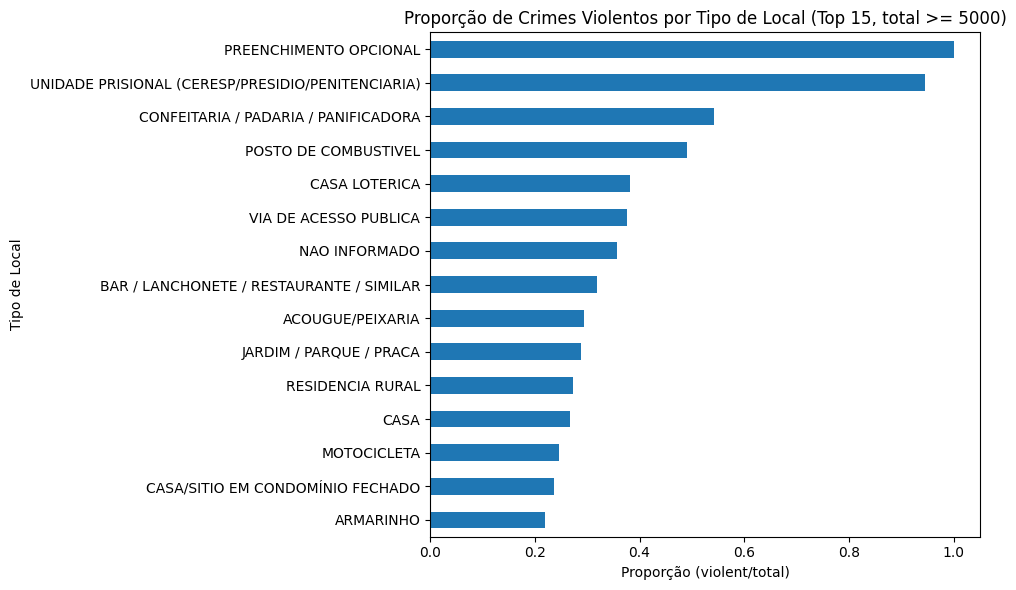

In [49]:
dataset_combinado.groupby("tipo_local")["qtde ocorrencias"].sum().sort_values(ascending=False).head(20)

In [47]:
violentos_por_tipo = (
    dataset_combinado
    .assign(viol_peso=lambda df: df["crime_violento"] * df["qtde ocorrencias"])
    .groupby("tipo_local")["viol_peso"]
    .sum()
    .sort_values(ascending=False)
)

participacao = violentos_por_tipo / violentos_por_tipo.sum()

participacao.head(15)

tipo_local
VIA DE ACESSO PUBLICA                                0.543750
CASA                                                 0.162284
NAO INFORMADO                                        0.097197
BAR / LANCHONETE / RESTAURANTE / SIMILAR             0.031631
OUTROS - ESTABELECIMENTOS COMERCIAIS / SERVICOS      0.016270
POSTO DE COMBUSTIVEL                                 0.015982
MERCEARIA / SACOLAO / SUPERMERCADO                   0.013591
CONFEITARIA / PADARIA / PANIFICADORA                 0.009609
FAZENDA                                              0.008380
APARTAMENTO                                          0.006738
SITIO                                                0.006576
LOJA DIVERSA                                         0.006555
ONIBUS                                               0.006123
DROGARIA / FARMACIA                                  0.005515
UNIDADE PRISIONAL (CERESP/PRESIDIO/PENITENCIARIA)    0.005188
Name: viol_peso, dtype: float64